# Study 772 — Album-Drop 🎧

*For the curious.* When Taylor Swift, Drake or Adele drops a record that shatters Spotify's single-day streaming record, surely the *stock* jumps? We put 27 genuinely blockbuster album releases (2018→2024) on the stand and asked the tape two plain questions: **does SPOT rally into the drop?** and **does it pop after?** The answer is a flat, boring zero.

## The claim, and why it's a clean test

A mega-album's release date is **known weeks ahead** (pre-orders, teaser singles), so *buy K sessions before, sell on the day* is calendar-known and zero-look-ahead. We measure SPOT's **abnormal** return (SPOT − SPY, total-return) so we're not just measuring the market or SPOT's beta. The economic prior is flat: Spotify earns from *subscriptions*, not a per-stream cut one album can move.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from album_drop import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching SPOT + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} drops resolved")


panel loaded; 27 of 27 drops resolved


## The album calendar we test (hardcoded from press releases)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['artist — album', 'release_date'])

,artist — album,release_date
0,Drake — Scorpion,2018-06-29
1,Travis Scott — Astroworld,2018-08-03
2,"Ariana Grande — thank u, next",2019-02-08
3,Taylor Swift — Lover,2019-08-23
4,Post Malone — Hollywood's Bleeding,2019-09-06
5,BTS — Map of the Soul: 7,2020-02-21
6,The Weeknd — After Hours,2020-03-20
7,Taylor Swift — folklore,2020-07-24
8,Ariana Grande — Positions,2020-10-30
9,Taylor Swift — evermore,2020-12-11


## The picture: mean cumulative abnormal return around the drop

Offset 0 is the release. Left of zero is the *run-up* (the supposed rally in); right of zero is the *reaction* window.

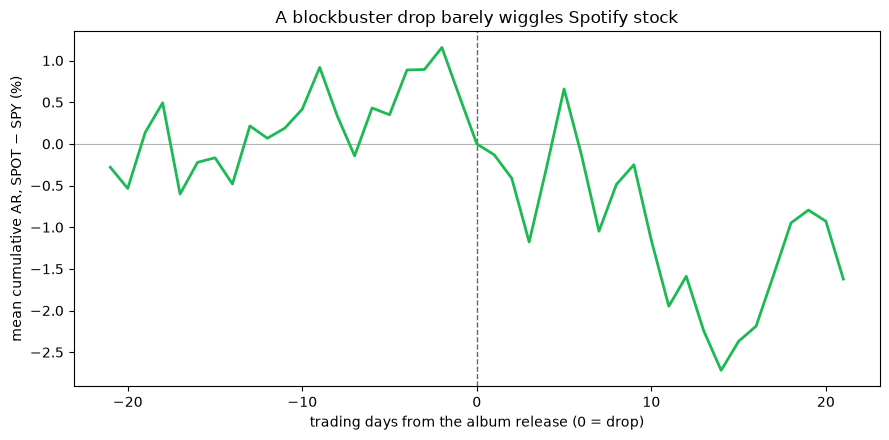

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#1db954', lw=2)
ax.set_xlabel('trading days from the album release (0 = drop)')
ax.set_ylabel('mean cumulative AR, SPOT − SPY (%)')
ax.set_title('A blockbuster drop barely wiggles Spotify stock')
plt.tight_layout(); plt.show()

## The numbers

| window | mean AR | *t* | hit rate |
|---|--:|--:|--:|
| 2-week run-up | +0.22% | +0.12 | 10/27 |
| 1-month run-up | +1.44% | +0.60 | 15/27 |
| 2-week reaction | -1.16% | -0.71 | 14/27 |
| 1-month reaction | -1.62% | -0.93 | 13/27 |

Every single cut is indistinguishable from noise — all |*t*| < 1, every hit rate near a coin-flip. The drop lights up the *charts*, not the *stock*.

In [4]:
rows = [('2wk run-up','pre_s'),('1mo run-up','pre_l'),('2wk reaction','post_s'),('1mo reaction','post_l')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<14s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  hit {hr["k"]}/{hr["n"]}')

2wk run-up     n=27  mean=+0.219%  t=+0.123  hit 10/27
1mo run-up     n=27  mean=+1.436%  t=+0.602  hit 15/27
2wk reaction   n=27  mean=-1.158%  t=-0.709  hit 14/27
1mo reaction   n=27  mean=-1.622%  t=-0.928  hit 13/27


## So what?

The famous *buy Spotify when the big album drops* idea is folklore: the stock doesn't rally in and doesn't pop after. One record-breaking streaming week is a rounding error against a ~600M-user subscription business the market has already priced. Verdict: **None signal, Mirage tradability.** The quants' notebook has the placebo, the jackknife, the costed leg and the synthetic control that *would* have caught a real effect.